<a href="https://colab.research.google.com/github/Nyymerria/carisurg-portfolio/blob/main/Assignmnet_2__Advanced_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully.")

Mounted at /content/drive
Drive mounted successfully.


In [6]:
import sys
print(f"Python version: {sys.version}")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Library successfully imported")

Library successfully imported


 **Cleaning the DBP Column**

In [8]:
file_path='/content/EmergencyTriageDataset_Reduced_Dirty.csv'
df_raw=pd.read_csv(file_path)


#maximum and minumum clinical values for diastolic blood pressure
# DPB being above 150mmHg and 30mmHg is considered impossible

#DBP>=80---> Hypertensive         DBP<=60------>Hypotensive


COLUMN='DBP'
maximun_dbp=150
minimum_dbp=30

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df_raw[COLUMN].unique()[:15]}")
print(f"Dtype: {df_raw[COLUMN].dtype}")
print()

# Step 1: Convert to numeric
df_raw[COLUMN] = pd.to_numeric(df_raw[COLUMN], errors='coerce')
print(f"After type conversion — NaNs: {df_raw[COLUMN].isnull().sum()}")
print(df_raw[COLUMN].describe())

=== Cleaning: DBP ===
Unique values: [ 67.  90. 105.  60.  80.  50.  70.  82.  89. 100.  84.  40.  61.  32.
  53.]
Dtype: float64

After type conversion — NaNs: 22
count    2183.000000
mean       77.479615
std        16.713289
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       173.000000
Name: DBP, dtype: float64


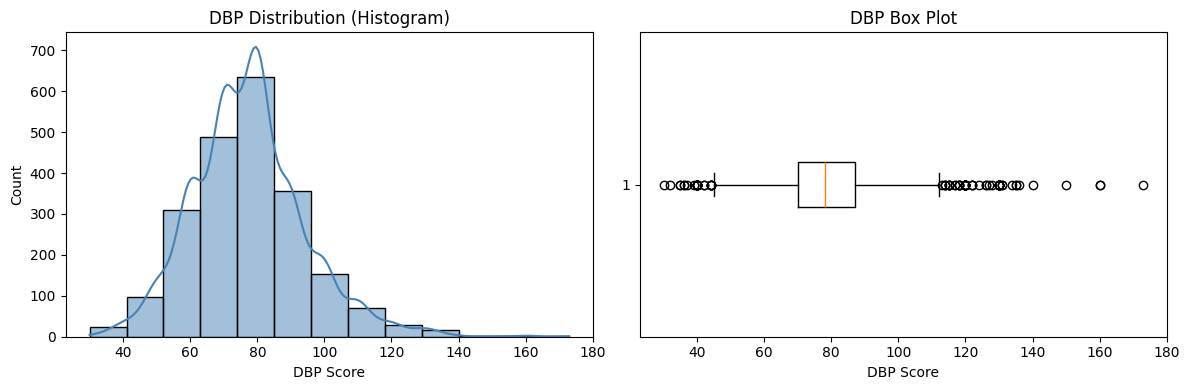

In [21]:


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram +  distribution curve in order to properly visualise date prior to cleaning
sns.histplot(df_raw['DBP'].dropna(),
             bins=13,
             kde=True,
             color='steelblue',
             edgecolor='black',
             ax=axes[0])

axes[0].set_xlabel('DBP Score')
axes[0].set_ylabel('Count')
axes[0].set_title('DBP Distribution (Histogram)')

# Box plot
axes[1].boxplot(df_raw['DBP'].dropna(), vert=False)
axes[1].set_xlabel('DBP Score')
axes[1].set_title('DBP Box Plot')

plt.tight_layout()
plt.show()

In [18]:
# Step 2: Range filter
invalid = df_raw[(df_raw[COLUMN] < minimum_dbp) | (df_raw[COLUMN] > maximun_dbp)]
print(f"Out-of-range values: {len(invalid)}")

df_raw.loc[(df_raw[COLUMN] < minimum_dbp) | (df_raw[COLUMN] > maximun_dbp), COLUMN] = np.nan

# Step 3: Impute — justify your choice (mean vs median vs mode)
impute_value = df_raw[COLUMN].median()
#As seen above the distribution is right skewed. The tail extends further to the right of histogram
# Thus in order replace NaN values median is used as it better represents the typical value in a skewed distribution because it is not influenced by outliers or the direction of the skew.

df_raw[COLUMN] = df_raw[COLUMN].fillna(impute_value)

print(f"\nAfter cleaning:")
print(df_raw[COLUMN].describe())
print(f"NaNs remaining: {df_raw[COLUMN].isnull().sum()}")

Out-of-range values: 3

After cleaning:
count    2205.000000
mean       77.367347
std        16.316160
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       150.000000
Name: DBP, dtype: float64
NaNs remaining: 0


**Cleaning the GCS Column**

GCS dtype: object
Unique GCS values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']
After conversion:
  dtype: float64
  NaN count: 44
  Range: 3.0 to 15.0


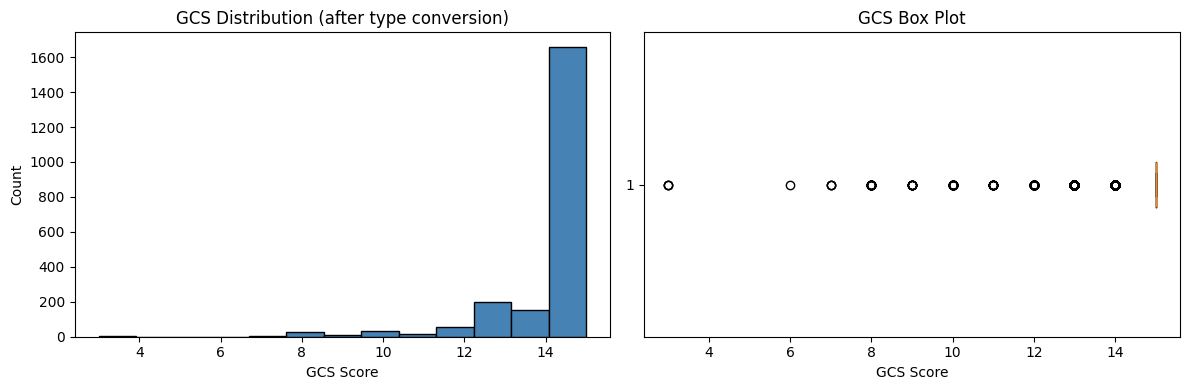

Plot saved as gcs_distribution


In [18]:

# GCS is currently stored as a string (object type)
print("GCS dtype:", df_raw['GCS'].dtype)
print("Unique GCS values:", df_raw['GCS'].unique())

# pd.to_numeric() with errors='coerce' converts numbers and turns
# everything non-numeric (like 'error') into NaN
df_raw['GCS'] = pd.to_numeric(df_raw['GCS'], errors='coerce')

print("After conversion:")
print(f"  dtype: {df_raw['GCS'].dtype}")
print(f"  NaN count: {df_raw['GCS'].isnull().sum()}")
print(f"  Range: {df_raw['GCS'].min()} to {df_raw['GCS'].max()}")
# Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(df_raw['GCS'].dropna(), bins=13, edgecolor='black', color='steelblue')
axes[0].set_xlabel('GCS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('GCS Distribution (after type conversion)')

axes[1].boxplot(df_raw['GCS'].dropna(), vert=False)
axes[1].set_xlabel('GCS Score')
axes[1].set_title('GCS Box Plot')

plt.tight_layout()
plt.savefig('gcs_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as gcs_distribution")

In [19]:
# Step 2: Flag physiologically impossible values
# GCS valid range: 3–15
invalid_gcs = df_raw[(df_raw['GCS'] < 3) | (df_raw['GCS'] > 15)]
print(f"GCS values outside valid range (3–15): {len(invalid_gcs)} rows")
print(invalid_gcs[['ID', 'GCS']].head(10))

# Step 3: Replace invalid values with NaN
df_raw.loc[(df_raw['GCS'] < 3) | (df_raw['GCS'] > 15), 'GCS'] = np.nan
print(f"NaN count after range filter: {df_raw['GCS'].isnull().sum()}")

# Compute the median and use it to fill NaN values
gcs_median = df_raw['GCS'].median()
print(f"GCS median (before imputation): {gcs_median}")

df_raw['GCS'] = df_raw['GCS'].fillna(gcs_median)

print(f"GCS after imputation:")
print(df_raw['GCS'].describe())
print(f"Remaining NaNs: {df_raw['GCS'].isnull().sum()}")

GCS values outside valid range (3–15): 0 rows
Empty DataFrame
Columns: [ID, GCS]
Index: []
NaN count after range filter: 44
GCS median (before imputation): 15.0
GCS after imputation:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
Remaining NaNs: 0


**Cleaning the SBP Column**

In [12]:
# SBP = Systolic Blood Pressure
# Range 50-250mmHg
# Extremely low SBP (<70) = shock risk. Extremely high (>200) = hypertensive crisis.

print("SBP unique values (sample):", df_raw['SBP'].unique()[:15])
print("SBP dtype:", df_raw['SBP'].dtype)


SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [13]:
# 1. Convert to numeric — non-numeric entries become NaN
df_raw['SBP'] = pd.to_numeric(df_raw['SBP'], errors='coerce')
print("After type conversion:")
print(df_raw['SBP'].describe())

After type conversion:
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64


In [14]:
# 2. Identify out-of-range values
invalid_sbp = df_raw[(df_raw['SBP'] < 50) | (df_raw['SBP'] > 250)]
print(f"Out-of-range SBP rows: {len(invalid_sbp)}")
print(invalid_sbp[['ID', 'SBP']].head())
# 3. Replace out-of-range with NaN, then impute with median
df_raw.loc[(df_raw['SBP'] < 50) | (df_raw['SBP'] > 250), 'SBP'] = np.nan
sbp_median = df_raw['SBP'].median()
df_raw['SBP'] = df_raw['SBP'].fillna(sbp_median)

print(f"SBP after cleaning: min={df_raw['SBP'].min()}, max={df_raw['SBP'].max()}, NaNs={df_raw['SBP'].isnull().sum()}")

Out-of-range SBP rows: 44
      ID    SBP
29    32   30.0
111  123  500.0
168  183  500.0
231  247   30.0
275  291  500.0
SBP after cleaning: min=55.0, max=250.0, NaNs=0


**Cleaning Temperature Column**

In [15]:
# First, look at the raw values
print("Temp unique values (sample):")
print(df_raw['Temp'].unique()[:20])
# Write a function to standardise everything to Celsius
def to_celsius(val):
    """Convert temperature value to Celsius float.
    Handles: plain numbers, strings ending in 'C', strings ending in 'F'.
    Returns NaN for anything unrecognisable.
    """
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])          # remove 'C', convert
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)               # assume Celsius already
    except ValueError:
        return np.nan                           # anything else -> NaN

df_raw['Temp'] = df_raw['Temp'].apply(to_celsius)

print("After standardisation:")
print(df_raw['Temp'].describe())

Temp unique values (sample):
['36.8' '37.0' '36.5' '39.0' '37.3' '36.7' '37.8' '38.5' '38.0' '37.6'
 '38.2' '37C' '36.2' '37.2' '37.5' nan '36.9' '39.6' '37.4' '50']
After standardisation:
count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [16]:
# Apply range filter: valid body temperature 32–43°C
df_raw.loc[(df_raw['Temp'] < 32) | (df_raw['Temp'] > 43), 'Temp'] = np.nan

# Impute with median
temp_median = round(df_raw['Temp'].median(), 1)
df_raw['Temp'] = df_raw['Temp'].fillna(temp_median)

print(f"Temp after cleaning: min={df_raw['Temp'].min():.1f}, max={df_raw['Temp'].max():.1f}, NaNs={df_raw['Temp'].isnull().sum()}")

Temp after cleaning: min=35.0, max=41.7, NaNs=0
